In [18]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

from sklearn import linear_model
import time

from catboost import CatBoostRegressor

import matplotlib.pyplot as plt



In [2]:
cpu_model = pd.read_csv('../datasets/processed/cpu_cleaned.csv')

In [3]:
X = cpu_model.drop('cpuMark', axis=1)
y = cpu_model['cpuMark']

In [4]:
X.head()

,threadMark,TDP,cores,testDate,Desktop,Laptop,Mobile/Embedded,Server,Unknown
0,3330,280.0,64,2022,1,0,0,0,0
1,2635,280.0,64,2021,0,0,0,1,0
2,2387,53.0,64,2021,0,0,0,1,0
3,2727,225.0,64,2021,0,0,0,1,0
4,2626,280.0,64,2020,1,0,0,0,0


In [5]:
y.head()

0    108822
1     88338
2     86006
3     85861
4     83971
Name: cpuMark, dtype: int64

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [7]:
time_start = time.perf_counter()
reg_linear = linear_model.LinearRegression()
reg_linear.fit(X_train,y_train)
end_time = time.perf_counter()

training_time = end_time - time_start

predict_linear = reg_linear.predict(X_test)

In [8]:
print("Test set shape: ",y_test.shape)
print("Prediction Shape: ",predict_linear.shape)

Test set shape:  (1148,)
Prediction Shape:  (1148,)


In [10]:
mae_reg_linear = mae(y_test, predict_linear)
rmse_reg_linear = rmse(y_test,predict_linear)
mape_reg_linear = mape(y_test,predict_linear)
r2_reg_linear = r2(y_test,predict_linear)
duration_reg_linear = end_time - time_start

print('Linear Regression MAE: {}'.format(mae_reg_linear))
print('Linear Regression RMSE: {}'.format(rmse_reg_linear))
print('Linear Regression MAPE: {}'.format(mape_reg_linear))
print('Linear Regression R2 Score: {}'.format(r2_reg_linear))
print('Training Duration: {:.6f} Seconds'.format(duration_reg_linear))

Linear Regression MAE: 2286.953953653316
Linear Regression RMSE: 3426.075511034746
Linear Regression MAPE: 1.9285600534835128
Linear Regression R2 Score: 0.877835897856433
Training Duration: 0.003490 Seconds


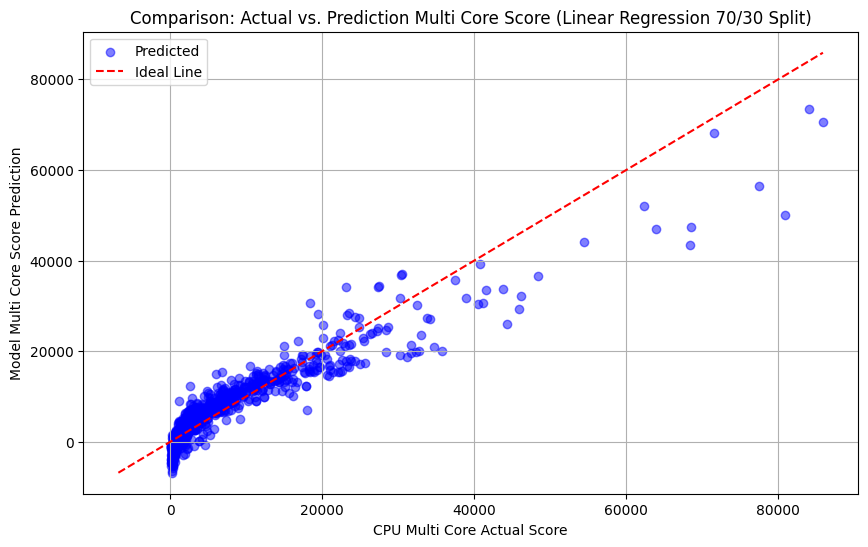

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_linear, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_linear.min())
max_val = max(y_test.max(), predict_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Multi Core Score (Linear Regression 70/30 Split)')
plt.xlabel('CPU Multi Core Actual Score')
plt.ylabel('Model Multi Core Score Prediction')
plt.legend()
plt.grid(True)


In [19]:
#CatBoost Regression Model Training

time_start = time.perf_counter()
reg_catboost = CatBoostRegressor()
reg_catboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_catboost = reg_catboost.predict(X_test)

Learning rate set to 0.047835
0:	learn: 9184.2397965	total: 134ms	remaining: 2m 14s
1:	learn: 8864.1372925	total: 135ms	remaining: 1m 7s
2:	learn: 8568.6969462	total: 136ms	remaining: 45.3s
3:	learn: 8273.3707052	total: 138ms	remaining: 34.3s
4:	learn: 7987.1089368	total: 139ms	remaining: 27.6s
5:	learn: 7710.6899452	total: 140ms	remaining: 23.2s
6:	learn: 7444.8193972	total: 141ms	remaining: 20s
7:	learn: 7191.6744223	total: 142ms	remaining: 17.6s
8:	learn: 6959.0239825	total: 143ms	remaining: 15.7s
9:	learn: 6740.3237325	total: 143ms	remaining: 14.2s
10:	learn: 6530.6916196	total: 144ms	remaining: 13s
11:	learn: 6323.6261663	total: 145ms	remaining: 11.9s
12:	learn: 6108.9969127	total: 146ms	remaining: 11.1s
13:	learn: 5914.9593368	total: 147ms	remaining: 10.4s
14:	learn: 5728.8866547	total: 148ms	remaining: 9.72s
15:	learn: 5569.2335406	total: 149ms	remaining: 9.16s
16:	learn: 5408.8500290	total: 150ms	remaining: 8.68s
17:	learn: 5239.2168358	total: 151ms	remaining: 8.24s
18:	learn: 

In [20]:
#Catboost Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_catboost = mae(y_test, predict_catboost)
rmse_catboost = rmse(y_test,predict_catboost)
mape_catboost = mape(y_test,predict_catboost)
r2_catboost = r2(y_test,predict_catboost)
duration_catboost = end_time - time_start

print('CatBoost Regression MAE: {}'.format(mae_catboost))
print('CatBoost Regression RMSE: {}'.format(rmse_catboost))
print('CatBoost Regression MAPE: {}'.format(mape_catboost))
print('CatBoost Regression R2: {}'.format(r2_catboost))
print('Training Duration: {:.6f} Seconds'.format(duration_catboost))

CatBoost Regression MAE: 687.540986202594
CatBoost Regression RMSE: 1505.3857170634199
CatBoost Regression MAPE: 0.17019254858134997
CatBoost Regression R2: 0.9764144869084221
Training Duration: 1.348300 Seconds


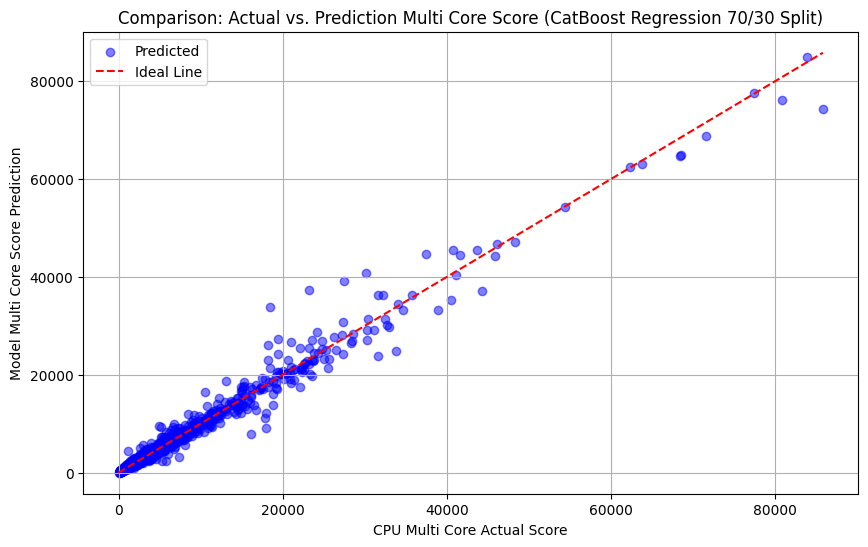

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_catboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_catboost.min())
max_val = max(y_test.max(), predict_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Multi Core Score (CatBoost Regression 70/30 Split)')
plt.xlabel('CPU Multi Core Actual Score')
plt.ylabel('Model Multi Core Score Prediction')
plt.legend()
plt.grid(True)

plt.show()